# 25 — Benchmark de Programación Dinámica (VFI): Mac Apple Silicon vs. GPU vs. MATLAB / runmat
**Curso:** Macroeconomía Avanzada (MAV 2026) | **Profesor:** Jorge Alonso Ortiz (ITAM)

---

## 0. Objetivos pedagógicos y computacionales

- Comparar el rendimiento computacional de la Iteración de la Función de Valor (VFI) a través de distintas arquitecturas de hardware y paradigmas de paralelismo.
- Medir el impacto de la memoria unificada (UMA) en Apple Silicon frente a GPUs dedicadas con PCIe.
- Evaluar ganancias de velocidad entre NumPy vectorizado, Numba JIT multi-hilo y tensores GPU (PyTorch MPS/CUDA).

---

## 1. Introducción y Arquitectura de Cómputo en Macroeconomía

La **Iteración de la Función de Valor (VFI)** es el caballo de batalla computacional de la macroeconomía moderna de agentes heterogéneos (modelos tipo Aiyagari, Krusell-Smith, HANK). La ecuación de Bellman:
$$ V_{n+1}(k, z) = \max_{k' \in \mathcal{K}} \left\{ u\big(z f(k) + (1-\delta)k - k'\big) + \beta \sum_{z'} \pi(z'|z) V_n(k', z') \right\} $$
exige evaluar $N_k \times N_{k'} \times N_z$ combinaciones en cada iteración hasta convergencia en la norma del supremo $\|V_{n+1} - V_n\|_\infty < \epsilon$.

Con mallas gruesas ($N_k = 500$, $N_z = 7$) la VFI de fuerza bruta tarda **menos de un segundo**
en una laptop moderna —lo verás en la tabla de la sección 8—: no es gratis, pero tampoco molesta.
El problema aparece al refinar la malla, porque el costo crece como $N_k^2$:

- $N_k = 10{,}000$: el paso de Bellman evalúa $N_k^2 N_z = 7\times 10^{8}$ combinaciones **por iteración**,
  y una corrida típica necesita ~300 iteraciones ($\beta^{300}\approx 5\times10^{-6}$ con $\beta=0.96$):
  más de $2\times 10^{11}$ evaluaciones en total.
- Peor aún, el tensor de retornos $R(k',k,z)$ pesa $N_k^2 N_z \times 8$ bytes $= 5.6$ **GB** en doble precisión.

Por eso la VFI de fuerza bruta no es un problema de *aritmética* sino de **ancho de banda de memoria**
y de **paralelismo de grano fino**: por cada número que se lee de memoria se hace una suma y una
comparación, y nada más. Ésa es la lección de arquitectura de este cuaderno, y la vamos a **medir**,
no a afirmar.

### Qué compara —y qué no— este benchmark

Se ejecutan aquí, **si el hardware está presente**:

1. **Mac Apple Silicon (M1/M2/M3/M4):**
   - **NumPy vectorizado** (CPU, doble precisión) — la línea base.
   - **Numba JIT con `parallel=True`** (CPU multi-hilo sobre P-cores + E-cores).
   - **GPU Metal** vía **PyTorch MPS** y, si está instalado, **Apple MLX**, aprovechando la
     Memoria Unificada (UMA) — sin copia host↔device por PCIe.
2. **NVIDIA GPU dedicada (T4 / L4 / A100 / H100):** **PyTorch CUDA**. Sólo corre si hay CUDA
   en *tu* máquina; en una Mac esa columna sencillamente no aparece.

**No** se ejecuta aquí:

- **MATLAB, `gpuArray` y `runmat`.** La sección 5 es un **listado de código** equivalente para que
  lo corras en tu propia instalación de MATLAB con `tic/toc`. Este cuaderno es Python: no lanza
  MATLAB ni produce columnas de MATLAB en la tabla final. Lo que veas en la tabla es lo que se midió.

> **Nota operativa (decisión D4 del curso).** Éste es un módulo **electivo** de arquitectura de
> cómputo: describe **hardware**, no una vía de trabajo alternativa. El curso **no** ofrece ninguna
> vía por navegador —ni Google Colab, ni Jupyter en la nube, ni MATLAB Online—. La única vía
> soportada es **instalación local**: Python local con `puremacro` (`pip install puremacro`) y
> MATLAB/Dynare instalados en tu máquina. Las GPUs NVIDIA aparecen aquí como **referencia de
> comparación**, no como camino de entrega: para tareas y exámenes basta tu instalación local.
> *(El nombre del archivo conserva por razones históricas la palabra "colab"; ignórala.)*

> **Regla del cuaderno: ninguna cifra en la prosa que el código no imprima.** Los tiempos dependen
> de tu máquina, así que las conclusiones cuantitativas las **calcula y las imprime el código**
> (secciones 7 a 9). Si tu tabla contradice una frase, la frase está mal: repórtalo.

## 2. Entorno y Detección Automática de Hardware
Identificamos el hardware disponible en tu máquina (CPU y núcleos, RAM, GPU Metal o NVIDIA CUDA).
La descripción de la máquina se guarda en `MAQUINA` y se estampa en el título de la figura: un
benchmark sin la máquina anotada no es reproducible ni comparable con el del compañero de al lado.

In [1]:
import os
import platform
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import torch
    TORCH_AVAILABLE = True
    HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    HAS_CUDA = torch.cuda.is_available()
except ImportError:
    TORCH_AVAILABLE = False
    HAS_MPS = False
    HAS_CUDA = False

try:
    import mlx.core as mx
    MLX_AVAILABLE = True
except ImportError:
    MLX_AVAILABLE = False

try:
    import numba
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False


def _cpu_nombre():
    """Nombre del CPU (macOS/Linux); cadena genérica si no se puede averiguar."""
    if sys.platform == "darwin":
        try:
            return subprocess.check_output(
                ["sysctl", "-n", "machdep.cpu.brand_string"], text=True
            ).strip()
        except Exception:
            return platform.processor() or "CPU desconocido"
    try:
        with open("/proc/cpuinfo") as fh:
            for linea in fh:
                if linea.startswith("model name"):
                    return linea.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "CPU desconocido"


def _ram_gb():
    """RAM física en GB (0.0 si no se puede averiguar)."""
    try:
        return os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1e9
    except (ValueError, AttributeError, OSError):
        return 0.0


CPU_NOMBRE = _cpu_nombre()
RAM_GB = _ram_gb()
N_NUCLEOS = os.cpu_count() or 1

print("=== DETECCIÓN DE HARDWARE Y BACKENDS ===")
print(f"Python: {sys.version.split()[0]}   ({platform.system()} {platform.machine()})")
print(f"CPU: {CPU_NOMBRE}  |  núcleos lógicos: {N_NUCLEOS}  |  RAM: {RAM_GB:.1f} GB")
print(f"NumPy version: {np.__version__}")
print(f"PyTorch instalado: {TORCH_AVAILABLE}")
print(f"  -> Apple Silicon GPU (MPS Metal): {HAS_MPS}")
print(f"  -> NVIDIA GPU (CUDA):             {HAS_CUDA}")
if HAS_CUDA:
    print(f"     GPU Nombre: {torch.cuda.get_device_name(0)}")
print(f"Apple MLX (Metal Native JIT): {MLX_AVAILABLE}")
if MLX_AVAILABLE:
    print(f"  -> Apple MLX Version: {mx.__version__}")
print(f"Numba JIT disponible: {NUMBA_AVAILABLE}")

_acel = "CUDA" if HAS_CUDA else ("Metal/MPS" if HAS_MPS else "sin GPU")
MAQUINA = f"{CPU_NOMBRE} · {N_NUCLEOS} núcleos · {RAM_GB:.0f} GB · {_acel}"
print(f"\nMÁQUINA (se estampa en la figura): {MAQUINA}")

=== DETECCIÓN DE HARDWARE Y BACKENDS ===
Python: 3.13.12   (Darwin arm64)
CPU: Apple M3 Pro  |  núcleos lógicos: 12  |  RAM: 38.7 GB
NumPy version: 2.4.6
PyTorch instalado: True
  -> Apple Silicon GPU (MPS Metal): True
  -> NVIDIA GPU (CUDA):             False
Apple MLX (Metal Native JIT): False
Numba JIT disponible: True

MÁQUINA (se estampa en la figura): Apple M3 Pro · 12 núcleos · 39 GB · Metal/MPS


## 3. Definición del Benchmark: Modelo Neoclásico Estocástico

Fijamos un problema RBC estocástico estándar en malla discreta:
- Utilidad: $u(c) = \dfrac{c^{1-\sigma} - 1}{1-\sigma}$ (con $\sigma = 2.0$).
- Producción: $y = z\, k^\alpha$ (con $\alpha = 0.36$, $\delta = 0.08$, $\beta = 0.96$).
- Proceso de productividad: $\log z' = \rho_z \log z + \varepsilon'$, $\varepsilon\sim N(0,\sigma_\varepsilon^2)$,
  con $\rho_z = 0.90$ y $\sigma_\varepsilon = 0.02$, **discretizado con Tauchen (1986)** en $N_z = 7$
  nodos y semiancho $m = 3$ desviaciones estándar incondicionales.

La discretización la hace `puremacro.vfi.tauchen`, la misma rutina que usan las lecciones de agentes
heterogéneos del paquete: Tauchen devuelve la malla **en logaritmos**, así que el nivel de
productividad es $z = \exp(\log z)$. La celda imprime la malla y verifica que $P$ sea fila-estocástica
—si la prosa dice "Tauchen con $\rho=0.90$", el código tiene que hacer exactamente eso—.

In [2]:
from puremacro.vfi import tauchen

alpha = 0.36
beta = 0.96
delta = 0.08
sigma_cons = 2.0

rho_z = 0.90
sigma_eps = 0.02
Nz = 7

log_z_grid, P_z = tauchen(Nz, rho_z, sigma_eps, m=3.0)
z_grid = np.exp(log_z_grid)

print("Tauchen(N_z=7, rho=0.90, sigma_eps=0.02, m=3)")
print("  malla de z (niveles):", np.round(z_grid, 4))
print("  suma de filas de P  :", np.round(P_z.sum(axis=1), 12))
assert np.allclose(P_z.sum(axis=1), 1.0), "P_z debe ser fila-estocástica"
assert P_z.shape == (Nz, Nz)


def setup_vfi_tensors(Nk, dtype=np.float64):
    """Genera la malla de capital y el tensor 3D de retornos R(k', k, z).

    ``dtype`` permite construir el mismo tensor en float64 (default) o float32,
    para medir cuánto de la ventaja de la GPU es sólo precisión sencilla.
    """
    k_ss = (alpha * beta / (1 - beta * (1 - delta))) ** (1 / (1 - alpha))
    k_grid = np.linspace(0.4 * k_ss, 1.8 * k_ss, Nk)

    # Tensor 3D de consumo: C(k', k, z) = z * k^alpha + (1-delta)*k - k'
    # Shape: (Nk_next, Nk_curr, Nz)
    k_curr = k_grid[None, :, None]    # (1, Nk, 1)
    k_next = k_grid[:, None, None]    # (Nk, 1, 1)
    z_val = z_grid[None, None, :]     # (1, 1, Nz)

    cons = z_val * (k_curr ** alpha) + (1 - delta) * k_curr - k_next
    infactible = cons <= 0
    cons[infactible] = 1e-10          # evita potencias de números no positivos

    if sigma_cons == 1.0:
        R = np.log(cons)
    else:
        R = (cons ** (1 - sigma_cons) - 1.0) / (1 - sigma_cons)

    R[infactible] = -1e12             # valor muy negativo para elecciones infactibles
    return k_grid.astype(dtype), R.astype(dtype, copy=False)


_k_ss = (alpha * beta / (1 - beta * (1 - delta))) ** (1 / (1 - alpha))
print(f"\nEstado estacionario determinista: k* = {_k_ss:.4f}  "
      f"(malla de capital: [{0.4*_k_ss:.3f}, {1.8*_k_ss:.3f}])")

Tauchen(N_z=7, rho=0.90, sigma_eps=0.02, m=3)
  malla de z (niveles): [0.8714 0.9123 0.9552 1.     1.047  1.0961 1.1476]
  suma de filas de P  : [1. 1. 1. 1. 1. 1. 1.]

Estado estacionario determinista: k* = 5.4468  (malla de capital: [2.179, 9.804])


## 4. Implementaciones en Python

Los cuatro *backends* resuelven **el mismo** problema con **el mismo** criterio de paro
($\|V_{n+1}-V_n\|_\infty < 10^{-6}$) y devuelven el mismo cuarteto
`(V, política, n_iter, segundos)`. Dos advertencias de método que valen para todo el cuaderno:

1. **Cada iteración cuesta igual, pero no todos hacen el mismo número de iteraciones.** Los
   *backends* de PyTorch y MLX corren en `float32` —porque Metal/MPS sencillamente **no** admite
   `float64`, y mantenemos CUDA en la misma precisión para que la comparación sea simétrica—, y en
   precisión sencilla la norma del supremo se atasca en el ruido de redondeo alrededor de
   $10^{-6}$: el bucle sigue girando decenas de iteraciones que ya no cambian nada (la tabla de
   iteraciones de la sección 8 lo muestra). Por eso el benchmark reporta **ms/iteración** y calcula
   las aceleraciones sobre esa base, no sobre el tiempo total.
2. **La política se recupera UNA vez, al final.** El algoritmo sólo necesita $V$ para iterar; el
   $\arg\max$ únicamente hace falta cuando $V$ ya convergió. Pedirlo en cada iteración es un error
   frecuente y **carísimo en NumPy**, porque `np.argmax` sobre el eje 0 de un tensor
   $(N_k, N_k, N_z)$ recorre la memoria a saltos. La sección 8b mide exactamente cuánto cuesta ese
   descuido: es el ejemplo canónico de una línea base artificialmente lenta que infla todas las
   aceleraciones del cuaderno.

### Implementación 1: NumPy Vectorizado (CPU)

In [3]:
def solve_vfi_numpy(R, P_z, beta, tol=1e-6, max_iter=2000, politica_en_bucle=False):
    """VFI vectorial puro en NumPy (Tensor 3D R: Nk_next x Nk_curr x Nz).

    ``politica_en_bucle=True`` reproduce el descuido habitual (calcular el argmax en
    cada iteración) para poder medir su costo en la sección 8b.
    """
    Nk, _, Nz = R.shape
    dt = R.dtype
    P = P_z.astype(dt, copy=False)
    beta_d = dt.type(beta)

    V = np.zeros((Nk, Nz), dtype=dt)
    pol_idx = np.zeros((Nk, Nz), dtype=np.int64)

    t0 = time.perf_counter()
    n_iter = 0
    sup_norm = 1.0

    while sup_norm > tol and n_iter < max_iter:
        n_iter += 1
        V_old = V

        # EV(k', z) = sum_z' V_old(k', z') * P(z'|z) -> Shape: (Nk, Nz)
        EV = V_old @ P.T

        # Bellman Tensor: R(k', k, z) + beta * EV(k', z) -> Shape: (Nk_next, Nk_curr, Nz)
        obj = R + beta_d * EV[:, None, :]

        # Maximizar sobre k' (axis 0). En el bucle basta el VALOR.
        if politica_en_bucle:
            pol_idx = np.argmax(obj, axis=0)
            V = np.take_along_axis(obj, pol_idx[None, :, :], axis=0)[0]
        else:
            V = np.max(obj, axis=0)

        sup_norm = float(np.max(np.abs(V - V_old)))

    # Política: una sola vez, con la V convergida (dentro del cronómetro: es parte de resolver).
    if not politica_en_bucle:
        obj = R + beta_d * (V @ P.T)[:, None, :]
        pol_idx = np.argmax(obj, axis=0)

    t1 = time.perf_counter()
    return V, pol_idx, n_iter, (t1 - t0)

### Implementación 2: PyTorch GPU/MPS (Apple Silicon Metal & NVIDIA CUDA)

`float32` no es una decisión de estilo: **MPS no soporta `float64`**. La consecuencia es doble y
hay que tenerla presente al leer la tabla: (i) el tensor pesa la mitad, y como el problema está
limitado por memoria eso es de por sí una ventaja real del acelerador; (ii) el criterio de paro se
vuelve más ruidoso y el conteo de iteraciones sube. La sección 8 mide cuánto de la ventaja es
precisión y cuánto es hardware.

In [4]:
def solve_vfi_pytorch(R, P_z, beta, device_str="cpu", tol=1e-6, max_iter=2000):
    """VFI acelerado en PyTorch para Apple Silicon MPS o NVIDIA CUDA."""
    if not TORCH_AVAILABLE:
        return None, None, 0, 0.0

    device = torch.device(device_str)

    # Transferencia a la GPU / acelerador
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    P_t = torch.tensor(P_z, dtype=torch.float32, device=device)

    Nk, _, Nz = R.shape
    V_t = torch.zeros((Nk, Nz), dtype=torch.float32, device=device)
    pol_idx_t = torch.zeros((Nk, Nz), dtype=torch.int64, device=device)

    # Sincronizar GPU antes del tiempo
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    t0 = time.perf_counter()
    n_iter = 0
    sup_norm = 1.0

    while sup_norm > tol and n_iter < max_iter:
        n_iter += 1
        V_old_t = V_t

        # EV = V_old @ P_z.T
        EV_t = torch.matmul(V_old_t, P_t.T)

        # Bellman Tensor: R + beta * EV[:, None, :]
        obj_t = R_t + beta * EV_t.unsqueeze(1)

        # Max en axis 0: en el bucle basta el VALOR (misma regla que en NumPy)
        V_t = torch.amax(obj_t, dim=0)

        sup_norm = torch.max(torch.abs(V_t - V_old_t)).item()

    # Política: una sola vez, con la V convergida
    obj_t = R_t + beta * torch.matmul(V_t, P_t.T).unsqueeze(1)
    pol_idx_t = torch.argmax(obj_t, dim=0)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

    t1 = time.perf_counter()
    elapsed = t1 - t0

    V_res = V_t.cpu().numpy()
    pol_res = pol_idx_t.cpu().numpy()
    return V_res, pol_res, n_iter, elapsed

### Implementación 3: Apple MLX (`mlx.core` Metal Native JIT para Mac M)

MLX es opcional (`pip install mlx`, sólo Apple Silicon). Si no está instalado, la función devuelve
tiempo cero y el benchmark **omite la columna sin ruido**: no aparecerá en la tabla ni en la figura.

In [5]:
if MLX_AVAILABLE:
    @mx.compile
    def _bellman_step_mlx(R_mx, V_mx, P_mx, beta):
        EV_mx = mx.matmul(V_mx, P_mx.T)
        obj_mx = R_mx + beta * mx.expand_dims(EV_mx, axis=1)
        return mx.max(obj_mx, axis=0)

    def _politica_mlx(R_mx, V_mx, P_mx, beta):
        EV_mx = mx.matmul(V_mx, P_mx.T)
        obj_mx = R_mx + beta * mx.expand_dims(EV_mx, axis=1)
        return mx.argmax(obj_mx, axis=0)

    def solve_vfi_mlx(R, P_z, beta, tol=1e-6, max_iter=2000):
        """VFI compilado nativo en Apple MLX con evaluacion en Metal GPU."""
        R_mx = mx.array(np.ascontiguousarray(R, dtype=np.float32))
        P_mx = mx.array(np.ascontiguousarray(P_z, dtype=np.float32))

        Nk, _, Nz = R.shape
        V_mx = mx.zeros((Nk, Nz), dtype=mx.float32)

        # Warmup de compilación Metal JIT (no debe contarse en el tiempo)
        V_test = _bellman_step_mlx(R_mx, V_mx, P_mx, beta)
        mx.eval(V_test)

        t0 = time.perf_counter()
        n_iter = 0
        sup_norm = 1.0

        while sup_norm > tol and n_iter < max_iter:
            n_iter += 1
            V_old_mx = V_mx

            V_mx = _bellman_step_mlx(R_mx, V_old_mx, P_mx, beta)
            mx.eval(V_mx)

            diff = mx.abs(V_mx - V_old_mx)
            mx.eval(diff)
            sup_norm = float(mx.max(diff))

        # Política: una sola vez, con la V convergida
        pol_mx = _politica_mlx(R_mx, V_mx, P_mx, beta)
        mx.eval(pol_mx)

        t1 = time.perf_counter()
        elapsed = t1 - t0

        V_res = np.array(V_mx)
        pol_res = np.array(pol_mx)
        return V_res, pol_res, n_iter, elapsed
else:
    def solve_vfi_mlx(R, P_z, beta, tol=1e-6, max_iter=2000):
        return None, None, 0, 0.0

### Implementación 4: Numba JIT (CPU Multi-hilo P-Cores/E-Cores en Mac)

La celda imprime cuántos hilos usa realmente y confirma que el decorador lleva
`parallel=True`: si la etiqueta de una columna dice "paralelo", hay que poder verificarlo.

In [6]:
if NUMBA_AVAILABLE:
    # OJO — y es el punto pedagógico de esta celda: `numba.prange` SOLO paraleliza si el
    # decorador lleva `parallel=True`. Sin esa bandera, `prange` es un alias de `range`, el
    # kernel corre en UN hilo... y la columna del benchmark seguiría llamándose "paralela".
    # Además, con `parallel=True` la norma del supremo NO puede acumularse con
    # `if diff > sup_norm: sup_norm = diff` dentro del prange: numba no lo reconoce como
    # reducción y falla al compilar. Guardamos el máximo de cada fila en `fila_dif` y
    # reducimos FUERA del bucle paralelo.
    @numba.njit(fastmath=True, parallel=True)
    def _vfi_numba_kernel(R, P_z, beta, V_in, tol, max_iter):
        Nk, _, Nz = R.shape
        V = V_in.copy()
        V_new = np.zeros_like(V)
        pol = np.zeros((Nk, Nz), dtype=numba.int64)
        fila_dif = np.zeros(Nk)          # máximo por fila; se reduce fuera del prange

        sup_norm = 1.0
        n_iter = 0

        while sup_norm > tol and n_iter < max_iter:
            n_iter += 1

            # EV(iap, z) = sum_zp V(iap, zp) * P_z(z, zp)
            EV = np.zeros((Nk, Nz))
            for iap in numba.prange(Nk):
                for z in range(Nz):
                    s = 0.0
                    for zp in range(Nz):
                        s += V[iap, zp] * P_z[z, zp]
                    EV[iap, z] = s

            # Bellman Step en paralelo sobre estados (ia, z)
            for ia in numba.prange(Nk):
                dif_max = 0.0
                for z in range(Nz):
                    best_val = -1e15
                    best_idx = 0
                    for iap in range(Nk):
                        val = R[iap, ia, z] + beta * EV[iap, z]
                        if val > best_val:
                            best_val = val
                            best_idx = iap
                    V_new[ia, z] = best_val
                    pol[ia, z] = best_idx

                    diff = abs(best_val - V[ia, z])
                    if diff > dif_max:
                        dif_max = diff
                fila_dif[ia] = dif_max

            sup_norm = fila_dif.max()    # reducción, ya fuera del bucle paralelo

            # Actualizar V
            for ia in numba.prange(Nk):
                for z in range(Nz):
                    V[ia, z] = V_new[ia, z]

        return V, pol, n_iter

    NUMBA_HILOS_MAX = numba.get_num_threads()
    print(f"Numba: {NUMBA_HILOS_MAX} hilos disponibles "
          f"(parallel={_vfi_numba_kernel.targetoptions.get('parallel')})")

    def solve_vfi_numba(R, P_z, beta, tol=1e-6, max_iter=2000):
        Nk, _, Nz = R.shape
        R64 = np.ascontiguousarray(R, dtype=np.float64)
        V_in = np.zeros((Nk, Nz))

        # Warmup de JIT compilation (fuera del cronómetro)
        _ = _vfi_numba_kernel(np.ascontiguousarray(R64[:10, :10, :]),
                              P_z, beta, V_in[:10, :], tol, 5)

        t0 = time.perf_counter()
        V, pol, n_iter = _vfi_numba_kernel(R64, P_z, beta, V_in, tol, max_iter)
        t1 = time.perf_counter()
        return V, pol, n_iter, (t1 - t0)
else:
    NUMBA_HILOS_MAX = 0

    def solve_vfi_numba(R, P_z, beta, tol=1e-6, max_iter=2000):
        return None, None, 0, 0.0

Numba: 12 hilos disponibles (parallel=True)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 5. Listado de referencia en MATLAB / runmat (NO se ejecuta en este cuaderno)

El código de abajo es el **equivalente en MATLAB** del mismo benchmark, para que lo corras en tu
instalación local y compares con `tic/toc`. Este cuaderno es Python puro: **no** invoca MATLAB, y
por lo tanto **no** habrá filas de MATLAB, `gpuArray` ni `runmat` en la tabla de la sección 8. Si
quieres el número, tienes que producirlo tú.

Dos advertencias antes de sacar conclusiones de la comparación:

- MATLAB tiene JIT desde hace más de una década; el viejo lugar común de que "los `for` de MATLAB
  son lentísimos" ya no describe bien al MATLAB moderno. Cualquier ventaja de `runmat` hay que
  **medirla**, no suponerla.
- Para que la comparación signifique algo, el problema tiene que ser el mismo: misma malla, misma
  $P_z$ de Tauchen, misma tolerancia y misma precisión.

```matlab
% =========================================================================
% BENCHMARK VFI EN MATLAB / RUNMAT (CPU y gpuArray)
% Mismo problema que el cuaderno: Tauchen(7, 0.90, 0.02), sigma = 2.
% =========================================================================
function [V, pol, n_iter, elapsed] = solve_vfi_matlab(Nk, beta, alpha, delta, sigma)
    % 1. Proceso de productividad: Tauchen en logs -> niveles
    %    (usa +puremacro.vfi.tauchen si lo tienes instalado en MATLAB)
    [log_z, P_z] = puremacro.vfi.tauchen(7, 0.90, 0.02, 3.0);
    z_grid = exp(log_z(:))';          % 1 x Nz, en NIVELES
    Nz = numel(z_grid);

    % 2. Malla de capital alrededor del estado estacionario determinista
    k_ss   = (alpha*beta/(1 - beta*(1-delta)))^(1/(1-alpha));
    k_grid = linspace(0.4*k_ss, 1.8*k_ss, Nk)';

    % 3. Tensor 3D de retornos R(k_next, k_curr, z)
    k_curr = reshape(k_grid, 1, Nk, 1);
    k_next = reshape(k_grid, Nk, 1, 1);
    z_val  = reshape(z_grid, 1, 1, Nz);

    cons = z_val .* (k_curr.^alpha) + (1-delta).*k_curr - k_next;
    infactible = (cons <= 0);
    cons(infactible) = 1e-10;
    R = (cons.^(1-sigma) - 1.0) / (1-sigma);
    R(infactible) = -1e12;

    % Para medir la GPU en MATLAB (o runmat), descomenta:
    % R = gpuArray(R); P_z = gpuArray(P_z);

    V = zeros(Nk, Nz);
    tol = 1e-6; max_iter = 2000;
    n_iter = 0; sup_norm = 1.0;

    tic;
    while sup_norm > tol && n_iter < max_iter
        n_iter = n_iter + 1;
        V_old = V;

        EV    = V_old * P_z';             % (Nk x Nz)
        EV_3d = reshape(EV, Nk, 1, Nz);

        obj = R + beta * EV_3d;
        [V, pol] = max(obj, [], 1);
        V   = reshape(V,   Nk, Nz);       % de (1 x Nk x Nz) a (Nk x Nz)
        pol = reshape(pol, Nk, Nz);

        sup_norm = max(abs(V(:) - V_old(:)));
    end
    elapsed = toc;
    % Si usaste gpuArray: V = gather(V); pol = gather(pol);
end
```

## 6. Ejecución del Benchmark y Escalamiento por Tamaño de Malla ($N_k$)

Medimos el tiempo para $N_k \in \{500, 1000, 2000, 4000\}$. **Cuidado con la memoria**: el tensor
$R$ en doble precisión pesa $N_k^2 N_z \times 8$ bytes y el paso de Bellman necesita otro tanto
para `obj`; con $N_k = 4000$ son ~0.9 GB cada uno. La celda estima ese costo y **descarta
automáticamente** las mallas que no quepan holgadamente en tu RAM, para que el cuaderno no
congele una máquina de 8 GB. En una laptop reciente la corrida completa toma unos pocos minutos.

In [7]:
grid_sizes = [500, 1000, 2000, 4000]

# Presupuesto de memoria: R (float64) + obj (float64) + copias float32 del acelerador.
FRACCION_RAM = 0.25


def _memoria_gb(Nk):
    """GB pico aproximados del paso de Bellman para una malla de tamaño Nk."""
    elems = Nk * Nk * Nz
    return (2 * 8 * elems + 2 * 4 * elems) / 1e9   # float64 (R, obj) + float32 (R_t, obj_t)


if RAM_GB > 0:
    grid_ok = [n for n in grid_sizes if _memoria_gb(n) <= FRACCION_RAM * RAM_GB]
    descartadas = [n for n in grid_sizes if n not in grid_ok]
    if descartadas:
        print(f"AVISO: con {RAM_GB:.0f} GB de RAM se omiten las mallas {descartadas} "
              f"(requieren {[round(_memoria_gb(n), 2) for n in descartadas]} GB de pico).")
    grid_sizes = grid_ok or [grid_sizes[0]]

results = []


def _registrar(Nk, backend, t, it, dtype):
    """Guarda un renglón del benchmark con tiempo total, iteraciones y ms/iteración."""
    results.append({"Nk": Nk, "Backend": backend, "Time": t, "Iter": it,
                    "ms_iter": 1000.0 * t / it if it else float("nan"),
                    "dtype": dtype})


print("=== INICIANDO BENCHMARK DE VFI ===")
print("(cada línea: tiempo total | iteraciones | ms por iteración | aceleración POR ITERACIÓN vs NumPy)")
for Nk in grid_sizes:
    print(f"\n--- Malla N_k = {Nk} "
          f"(evaluaciones por iteración: {Nk*Nk*Nz:,} | tensor R: {8*Nk*Nk*Nz/1e9:.2f} GB f64) ---")
    k_grid, R = setup_vfi_tensors(Nk)

    def _linea(etiqueta, t, it, ms_base=None):
        ms = 1000.0 * t / it
        extra = "" if ms_base is None else f" | {ms_base/ms:5.1f}x"
        print(f"  {etiqueta:<30s} {t:8.3f} s | {it:4d} it | {ms:8.2f} ms/it{extra}")
        return ms

    # 1. NumPy CPU (línea base, float64)
    _, _, it_np, t_np = solve_vfi_numpy(R, P_z, beta)
    ms_np = _linea("[1] NumPy (CPU, f64)", t_np, it_np)
    _registrar(Nk, "NumPy (CPU)", t_np, it_np, "f64")

    # 2. PyTorch CPU
    if TORCH_AVAILABLE:
        _, _, it_pt, t_pt = solve_vfi_pytorch(R, P_z, beta, device_str="cpu")
        _linea("[2] PyTorch (CPU, f32)", t_pt, it_pt, ms_np)
        _registrar(Nk, "PyTorch (CPU)", t_pt, it_pt, "f32")

    # 3. PyTorch MPS (Apple Silicon GPU)
    if HAS_MPS:
        _, _, it_mps, t_mps = solve_vfi_pytorch(R, P_z, beta, device_str="mps")
        _linea("[3] Apple Silicon MPS (f32)", t_mps, it_mps, ms_np)
        _registrar(Nk, "Apple Silicon (MPS GPU)", t_mps, it_mps, "f32")

    # 3b. Apple MLX (Metal Native JIT)
    if MLX_AVAILABLE:
        _, _, it_mlx, t_mlx = solve_vfi_mlx(R, P_z, beta)
        _linea("[3b] Apple MLX (Metal JIT, f32)", t_mlx, it_mlx, ms_np)
        _registrar(Nk, "Apple MLX (Metal Native JIT)", t_mlx, it_mlx, "f32")

    # 4. PyTorch CUDA (NVIDIA GPU dedicada)
    if HAS_CUDA:
        _, _, it_cuda, t_cuda = solve_vfi_pytorch(R, P_z, beta, device_str="cuda")
        _linea("[4] NVIDIA CUDA (f32)", t_cuda, it_cuda, ms_np)
        _registrar(Nk, "NVIDIA CUDA (GPU dedicada)", t_cuda, it_cuda, "f32")

    # 5. Numba JIT (CPU Parallel)
    if NUMBA_AVAILABLE:
        _, _, it_nb, t_nb = solve_vfi_numba(R, P_z, beta)
        _linea(f"[5] Numba JIT ({NUMBA_HILOS_MAX} hilos, f64)", t_nb, it_nb, ms_np)
        _registrar(Nk, f"Numba JIT (CPU paralelo, {NUMBA_HILOS_MAX} hilos)", t_nb, it_nb, "f64")

df_res = pd.DataFrame(results)

=== INICIANDO BENCHMARK DE VFI ===
(cada línea: tiempo total | iteraciones | ms por iteración | aceleración POR ITERACIÓN vs NumPy)

--- Malla N_k = 500 (evaluaciones por iteración: 1,750,000 | tensor R: 0.01 GB f64) ---


  [1] NumPy (CPU, f64)              0.615 s |  304 it |     2.02 ms/it


  [2] PyTorch (CPU, f32)            0.329 s |  382 it |     0.86 ms/it |   2.4x


  [3] Apple Silicon MPS (f32)       0.430 s |  372 it |     1.16 ms/it |   1.8x


  [5] Numba JIT (12 hilos, f64)     0.136 s |  304 it |     0.45 ms/it |   4.5x

--- Malla N_k = 1000 (evaluaciones por iteración: 7,000,000 | tensor R: 0.06 GB f64) ---


...

  [5] Numba JIT (12 hilos, f64)     1.757 s |  304 it |     5.78 ms/it |   8.3x

--- Malla N_k = 4000 (evaluaciones por iteración: 112,000,000 | tensor R: 0.90 GB f64) ---


  [1] NumPy (CPU, f64)             74.272 s |  304 it |   244.32 ms/it


  [2] PyTorch (CPU, f32)           14.844 s |  393 it |    37.77 ms/it |   6.5x


  [3] Apple Silicon MPS (f32)      10.887 s |  395 it |    27.56 ms/it |   8.9x


  [5] Numba JIT (12 hilos, f64)    13.461 s |  304 it |    44.28 ms/it |   5.5x


## 7. Gráfico de Escalamiento

Dos paneles en escala log-log: a la izquierda el **tiempo total** (lo que sufre el usuario) y a la
derecha el **tiempo por iteración** (lo que compara arquitecturas sin contaminarse con el conteo
de iteraciones, que cambia con la precisión). La pendiente es la que hay que mirar: la VFI de
fuerza bruta es $O(N_k^2)$, así que pendiente $\approx 2$ significa que el *backend* ya está en su
régimen asintótico; una pendiente menor en los tamaños chicos delata costos fijos (compilación,
lanzamiento de kernels, sincronización).

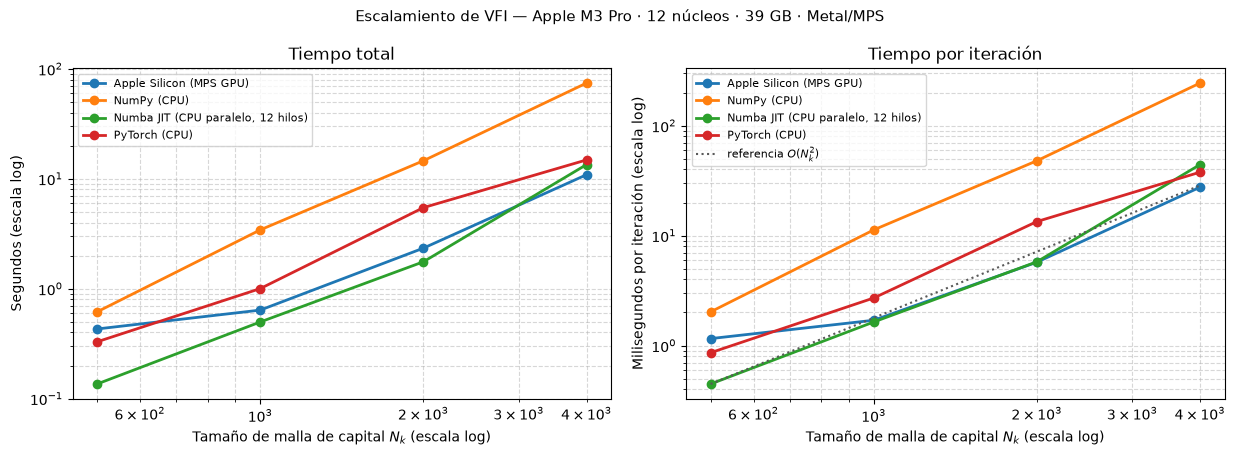

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), sharex=True)

for eje, col, titulo in [
    (axes[0], "Time", "Tiempo total"),
    (axes[1], "ms_iter", "Tiempo por iteración"),
]:
    for backend, group in df_res.groupby("Backend"):
        g = group.sort_values("Nk")
        eje.plot(g["Nk"], g[col], marker="o", lw=2, label=backend)
    eje.set_xscale("log")
    eje.set_yscale("log")
    eje.set_xlabel("Tamaño de malla de capital $N_k$ (escala log)")
    eje.set_title(titulo)
    eje.grid(True, which="both", ls="--", alpha=0.5)

axes[0].set_ylabel("Segundos (escala log)")
axes[1].set_ylabel("Milisegundos por iteración (escala log)")

# Pendiente de referencia O(N_k^2)
_x = np.array(sorted(df_res["Nk"].unique()), dtype=float)
if len(_x) >= 2:
    _y0 = df_res.loc[df_res["Nk"] == _x[0], "ms_iter"].min()
    axes[1].plot(_x, _y0 * (_x / _x[0]) ** 2, ls=":", color="0.35", lw=1.5,
                 label=r"referencia $O(N_k^2)$")

axes[0].legend(fontsize=8, loc="upper left")
axes[1].legend(fontsize=8, loc="upper left")
fig.suptitle(f"Escalamiento de VFI — {MAQUINA}", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Tablas y verificaciones cuantitativas

Tres cosas que el código calcula **por ti**, para que ninguna conclusión dependa de lo que diga la
prosa: (i) la tabla de tiempos y de ms/iteración; (ii) quién gana en cada malla; (iii) cuánto de la
ventaja de los aceleradores es sólo `float32`.

In [9]:
piv_t = df_res.pivot(index="Nk", columns="Backend", values="Time")
piv_ms = df_res.pivot(index="Nk", columns="Backend", values="ms_iter")
piv_it = df_res.pivot(index="Nk", columns="Backend", values="Iter")

print("=== TIEMPO TOTAL (SEGUNDOS) ===")
print(piv_t.round(4).to_string())
print("\n=== TIEMPO POR ITERACIÓN (MILISEGUNDOS) ===")
print(piv_ms.round(3).to_string())
print("\n=== ITERACIONES HASTA CONVERGENCIA ===")
print(piv_it.astype("Int64").to_string())
print("\nNota: los backends en f32 (MPS/CUDA/MLX/PyTorch CPU) suelen necesitar MÁS iteraciones que")
print("      los de f64 (NumPy/Numba): la norma del supremo se atasca en el ruido de redondeo.")

print("\n=== GANADOR POR TAMAÑO DE MALLA (tiempo total) ===")
for Nk, g in df_res.groupby("Nk"):
    g = g.sort_values("Time")
    mejor = g.iloc[0]
    segundo = g.iloc[1] if len(g) > 1 else None
    linea = f"  N_k = {Nk:5d}: {mejor['Backend']} ({mejor['Time']:.3f} s)"
    if segundo is not None:
        linea += f"  —  2º: {segundo['Backend']} ({segundo['Time']:.3f} s, {segundo['Time']/mejor['Time']:.2f}x más lento)"
    print(linea)

# Escalamiento empírico: pendiente de log(ms/iter) contra log(Nk)
print("\n=== PENDIENTE EMPÍRICA d log(ms/iter) / d log(N_k)   (la teoría dice 2) ===")
for backend, g in df_res.groupby("Backend"):
    g = g.sort_values("Nk")
    if len(g) >= 2:
        p = np.polyfit(np.log(g["Nk"].to_numpy(float)),
                       np.log(g["ms_iter"].to_numpy(float)), 1)[0]
        print(f"  {backend:42s} {p:5.2f}")

=== TIEMPO TOTAL (SEGUNDOS) ===
Backend  Apple Silicon (MPS GPU)  NumPy (CPU)  Numba JIT (CPU paralelo, 12 hilos)  PyTorch (CPU)
Nk                                                                                              
500                       0.4299       0.6152                              0.1357         0.3286
1000                      0.6383       3.4267                              0.4977         1.0017
2000                      2.3377      14.5845                              1.7565         5.4620
4000                     10.8867      74.2719                             13.4610        14.8437

=== TIEMPO POR ITERACIÓN (MILISEGUNDOS) ===
Backend  Apple Silicon (MPS GPU)  NumPy (CPU)  Numba JIT (CPU paralelo, 12 hilos)  PyTorch (CPU)
Nk                                                                                              
500                        1.156        2.024                               0.447          0.860
1000                       1.698       11.272     

### 8a. ¿Cuánto de la ventaja del acelerador es sólo precisión sencilla?

Control barato y decisivo: **el mismo** kernel de NumPy, en la **misma** CPU, con el tensor en
`float32` en vez de `float64`. Si el problema estuviera limitado por aritmética, cambiar la
precisión casi no debería importar (ganancia $\approx 1$); si estuviera limitado **sólo** por el
ancho de banda, mover la mitad de los bytes debería duplicar la velocidad (ganancia $\approx 2$).
El número que imprima tu máquina la coloca entre esos dos extremos —y es el descuento que hay que
aplicarle a la columna MPS antes de atribuirle su ventaja a la GPU—.

In [10]:
Nk_ctrl = min(1000, max(grid_sizes))
_, R64 = setup_vfi_tensors(Nk_ctrl, dtype=np.float64)
_, R32 = setup_vfi_tensors(Nk_ctrl, dtype=np.float32)

_, _, it64, t64 = solve_vfi_numpy(R64, P_z, beta)
_, _, it32, t32 = solve_vfi_numpy(R32, P_z, beta)
ms64, ms32 = 1000 * t64 / it64, 1000 * t32 / it32

print(f"Control de precisión en NumPy (misma CPU, N_k = {Nk_ctrl}):")
print(f"  float64: {t64:6.3f} s | {it64:4d} it | {ms64:7.2f} ms/it")
print(f"  float32: {t32:6.3f} s | {it32:4d} it | {ms32:7.2f} ms/it")
print(f"  -> ganancia POR ITERACIÓN al pasar a f32, sin cambiar de hardware: {ms64/ms32:.2f}x")
print(f"  -> iteraciones extra que cuesta el ruido de f32: {it32 - it64}")
print("\nLectura: esa fracción de la ventaja de MPS/CUDA en la tabla NO es la GPU, es la precisión.")

Control de precisión en NumPy (misma CPU, N_k = 1000):
  float64:  3.128 s |  304 it |   10.29 ms/it
  float32:  2.909 s |  370 it |    7.86 ms/it
  -> ganancia POR ITERACIÓN al pasar a f32, sin cambiar de hardware: 1.31x
  -> iteraciones extra que cuesta el ruido de f32: 66

Lectura: esa fracción de la ventaja de MPS/CUDA en la tabla NO es la GPU, es la precisión.


### 8b. Qué tan fácil es inflar un *speedup*: la línea base

Mismo hardware, mismo lenguaje, mismo problema; único cambio: pedir el $\arg\max$ **dentro** del
bucle en vez de una sola vez al converger. Es la versión que uno escribe sin pensar, y es la que
usan muchos benchmarks de GPU publicados como línea base de CPU. Compara los dos números y
después mira cuánto cambiarían todas las aceleraciones de la tabla de la sección 8.

In [11]:
_, _, it_ing, t_ing = solve_vfi_numpy(R64, P_z, beta, politica_en_bucle=True)
ms_ing = 1000 * t_ing / it_ing

print(f"Línea base de NumPy en f64 (N_k = {Nk_ctrl}), misma máquina:")
print(f"  argmax UNA vez al final (la del cuaderno): {t64:7.3f} s | {ms64:8.2f} ms/it")
print(f"  argmax en CADA iteración (la ingenua):     {t_ing:7.3f} s | {ms_ing:8.2f} ms/it")
print(f"  -> la versión ingenua es {ms_ing/ms64:.2f}x más lenta POR ITERACIÓN,")
print(f"     y adoptarla como línea base multiplicaría TODAS las aceleraciones")
print(f"     de la sección 8 por ese mismo {ms_ing/ms64:.2f}, sin que nada real mejorara.")
print("\nMoraleja: antes de creerse un 'Nx más rápido', pregunta contra qué se midió.")

Línea base de NumPy en f64 (N_k = 1000), misma máquina:
  argmax UNA vez al final (la del cuaderno):   3.128 s |    10.29 ms/it
  argmax en CADA iteración (la ingenua):       6.734 s |    22.15 ms/it
  -> la versión ingenua es 2.15x más lenta POR ITERACIÓN,
     y adoptarla como línea base multiplicaría TODAS las aceleraciones
     de la sección 8 por ese mismo 2.15, sin que nada real mejorara.

Moraleja: antes de creerse un 'Nx más rápido', pregunta contra qué se midió.


### 8c. ¿El *speedup* es igual al número de núcleos? Escalamiento por hilos

Aquí se comprueba la afirmación central del cuaderno. Corremos **el mismo kernel de Numba**
variando `numba.set_num_threads`. Si el paso de Bellman estuviera limitado por aritmética, el
tiempo caería casi como $1/\text{hilos}$; si está limitado por **ancho de banda de memoria**, la
curva se aplana muy por debajo del número de hilos, porque todos los núcleos comparten el mismo bus.

In [12]:
if NUMBA_AVAILABLE and NUMBA_HILOS_MAX > 1:
    Nk_hilos = min(1000, max(grid_sizes))
    _, R_h = setup_vfi_tensors(Nk_hilos)

    hilos_lista = sorted({h for h in [1, 2, 4, 8, NUMBA_HILOS_MAX] if h <= NUMBA_HILOS_MAX})
    filas = []
    for h in hilos_lista:
        numba.set_num_threads(h)
        _, _, it_h, t_h = solve_vfi_numba(R_h, P_z, beta)
        filas.append({"hilos": h, "s": t_h, "it": it_h})
    numba.set_num_threads(NUMBA_HILOS_MAX)   # restaurar

    df_hilos = pd.DataFrame(filas)
    t1h = df_hilos.loc[df_hilos["hilos"] == 1, "s"].iloc[0]
    df_hilos["speedup"] = t1h / df_hilos["s"]
    df_hilos["eficiencia"] = df_hilos["speedup"] / df_hilos["hilos"]

    print(f"Escalamiento por hilos del kernel de Numba (N_k = {Nk_hilos}):")
    print(df_hilos.round(3).to_string(index=False))
    sp_max = df_hilos["speedup"].iloc[-1]
    print(f"\n  Con {NUMBA_HILOS_MAX} hilos el speedup medido es {sp_max:.1f}x "
          f"(eficiencia {100*sp_max/NUMBA_HILOS_MAX:.0f}% del ideal).")
    print("  Contar núcleos NO predice el tiempo de pared: el cuello de botella es la memoria.")
else:
    df_hilos = None
    print("Numba no disponible (o un solo hilo): se omite el escalamiento por hilos.")

Escalamiento por hilos del kernel de Numba (N_k = 1000):
 hilos     s  it  speedup  eficiencia
     1 1.795 304    1.000       1.000
     2 1.000 304    1.796       0.898
     4 0.521 304    3.446       0.862
     8 0.481 304    3.733       0.467
    12 0.412 304    4.352       0.363

  Con 12 hilos el speedup medido es 4.4x (eficiencia 36% del ideal).
  Contar núcleos NO predice el tiempo de pared: el cuello de botella es la memoria.


## 9. Lectura de los resultados y recomendaciones operativas

La celda siguiente **redacta la conclusión a partir de tu tabla**, no al revés. Léela antes de
seguir con el texto: si tu máquina no es una Mac Apple Silicon reciente, tu ranking puede diferir
y el texto de abajo está escrito para no contradecirlo.

In [13]:
Nk_max = int(df_res["Nk"].max())
g_max = df_res[df_res["Nk"] == Nk_max].sort_values("Time")
base = df_res[(df_res["Nk"] == Nk_max) & (df_res["Backend"] == "NumPy (CPU)")].iloc[0]

print(f"=== RESUMEN AUTOMÁTICO (malla más grande medida: N_k = {Nk_max}) ===")
print(f"Máquina: {MAQUINA}")
print("Ordenado por TIEMPO TOTAL; el paréntesis es POR ITERACIÓN, así que los dos")
print("órdenes pueden diferir cuando un backend hace más iteraciones que otro.\n")
for _, fila in g_max.iterrows():
    print(f"  {fila['Backend']:42s} {fila['Time']:8.3f} s   "
          f"({base['ms_iter']/fila['ms_iter']:5.1f}x por iteración vs NumPy)")

gana_gpu = {"Apple Silicon (MPS GPU)", "NVIDIA CUDA (GPU dedicada)", "Apple MLX (Metal Native JIT)"}
mejor_backend = g_max.iloc[0]["Backend"]
print(f"\nEn esta máquina y en N_k = {Nk_max} gana: {mejor_backend}")
print("  -> categoría: " + ("acelerador GPU" if mejor_backend in gana_gpu else "CPU (vectorizado o JIT multi-hilo)"))
if not HAS_CUDA:
    print("\nSin GPU NVIDIA en esta máquina: la columna CUDA no se midió y no aparece en la tabla.")
if not MLX_AVAILABLE:
    print("Sin Apple MLX instalado: esa columna tampoco se midió.")
print("Ninguna fila de MATLAB / gpuArray / runmat: este cuaderno no ejecuta MATLAB (sección 5).")

=== RESUMEN AUTOMÁTICO (malla más grande medida: N_k = 4000) ===
Máquina: Apple M3 Pro · 12 núcleos · 39 GB · Metal/MPS
Ordenado por TIEMPO TOTAL; el paréntesis es POR ITERACIÓN, así que los dos
órdenes pueden diferir cuando un backend hace más iteraciones que otro.

  Apple Silicon (MPS GPU)                      10.887 s   (  8.9x por iteración vs NumPy)
  Numba JIT (CPU paralelo, 12 hilos)           13.461 s   (  5.5x por iteración vs NumPy)
  PyTorch (CPU)                                14.844 s   (  6.5x por iteración vs NumPy)
  NumPy (CPU)                                  74.272 s   (  1.0x por iteración vs NumPy)

En esta máquina y en N_k = 4000 gana: Apple Silicon (MPS GPU)
  -> categoría: acelerador GPU

Sin GPU NVIDIA en esta máquina: la columna CUDA no se midió y no aparece en la tabla.
Sin Apple MLX instalado: esa columna tampoco se midió.
Ninguna fila de MATLAB / gpuArray / runmat: este cuaderno no ejecuta MATLAB (sección 5).


### Recomendaciones pedagógicas y operativas para MAV 2026

1. **La línea base honesta es la que decide todo.** El NumPy de este cuaderno itera sólo sobre el
   valor (`np.max`) y recupera la política una vez al converger. La sección 8b mide, en tu máquina,
   cuánto se degrada esa misma línea base si se pide el `argmax` en cada iteración —y por ese mismo
   factor se inflarían **todas** las aceleraciones de la tabla, sin que nada real hubiera mejorado.
   Antes de reportar un *speedup*, pregúntate contra qué lo estás midiendo.

2. **CPU multi-hilo (Numba) es competitivo mucho más lejos de lo que la intuición sugiere.** En una
   Mac Apple Silicon, el kernel de Numba con `parallel=True` pelea de tú a tú con la GPU Metal en
   el rango de mallas de este cuaderno; quién gana exactamente depende de tu máquina y lo dice el
   resumen automático de arriba. La ventaja práctica del camino CPU es que corre en `float64`,
   sin el ruido de convergencia de `float32`.

3. **Lee la aceleración de Numba con la cabeza fría.** La sección 8c mide el escalamiento por
   hilos: la eficiencia paralela cae bien por debajo del 100% mucho antes de agotar los núcleos,
   porque el paso de Bellman está limitado por **ancho de banda de memoria**, no por aritmética,
   y los E-cores comparten el mismo bus que los P-cores. **Contar núcleos no predice el tiempo de
   pared.**

4. **La memoria unificada de la Mac cambia el punto de cruce.** En una GPU discreta hay que
   amortizar la copia host→device por PCIe antes de ganar algo; en Apple Silicon no hay tal copia,
   así que la GPU es competitiva desde mallas mucho más pequeñas. Eso es lo que hace atractivo el
   camino Metal para trabajo interactivo.

5. **Cuidado con extrapolar.** Este cuaderno mide hasta $N_k = 4{,}000$ (menos si tu RAM obligó a
   recortar). Todo lo que se diga sobre $N_k \ge 10{,}000$ o sobre GPUs A100/H100 es **conjetura
   hasta que lo midas**: a esas escalas el tensor $R$ deja de caber en memoria y hay que reescribir
   el algoritmo por bloques, que es otro problema. La curva de la sección 7 y su pendiente
   empírica son el instrumento para extrapolar con cuidado, no la intuición.

6. **Primero el algoritmo, después el hardware.** Esta VFI es fuerza bruta, $O(N_k^2 N_z)$ por
   iteración. Monotonía de la política, concavidad y aceleración de Howard reducen el orden o el
   número de iteraciones y se combinan con cualquier acelerador; cambiar de arquitectura, no.

7. **Vía del curso (D4).** Nada de esto altera la logística: se trabaja en **instalación local**
   (`pip install puremacro`, MATLAB/Dynare locales). No hay Colab, ni Jupyter en la nube, ni MATLAB
   Online. Este módulo es electivo: nadie necesita una GPU para aprobar MAV.

## 10. Preguntas para pensar

1. **La etiqueta y el hecho.** El kernel de Numba usa `numba.prange`, pero eso por sí solo
   no lo hace paralelo. ¿Qué hay que verificar en el código —y qué hay que imprimir en la
   salida— para que la columna "CPU paralelo" del benchmark sea una afirmación comprobable
   y no una etiqueta? Corre la sección 8c con `parallel=False` en el decorador y describe
   qué cambia en la tabla de escalamiento por hilos.
2. **Por qué el *speedup* no es el número de núcleos.** Con $N_k$ nodos, el paso de Bellman
   lee $N_k^2 N_z$ números de `R` y hace una suma y una comparación por cada uno. Calcula la razón
   operaciones/byte y explica por qué el cuello de botella es el **ancho de banda de
   memoria**. Contrasta tu razonamiento con la eficiencia paralela que imprimió la sección 8c.
   ¿Qué implica eso para la ganancia de añadir E-cores?
3. **Precisión contra hardware.** La sección 8a mide cuánto gana el **mismo** CPU al pasar de
   `float64` a `float32`. Con ese número, descuenta la parte "precisión" de la aceleración que
   muestra MPS en tu tabla: ¿cuánto queda atribuible a la GPU? ¿Y por qué esa misma precisión
   sencilla hace que MPS necesite más iteraciones para el mismo `tol`?
4. **Cuándo conviene la GPU.** La transferencia host↔device tiene un costo fijo. Con los
   tiempos de tu tabla y las pendientes empíricas de la sección 8, estima el $N_k$ de cruce a
   partir del cual la GPU gana. ¿Por qué el cruce está en un $N_k$ mucho menor en una Mac con
   memoria unificada que en una máquina con GPU dedicada y PCIe?
5. **El algoritmo antes que el hardware.** Esta VFI es de fuerza bruta: $O(N_k^2 N_z)$ por
   iteración. ¿Cuánto ganarías con monotonía de la política, concavidad (búsqueda por
   sección áurea) o aceleración de Howard, y cómo se compara esa ganancia con la de cambiar
   de arquitectura?
6. **El límite duro.** ¿A partir de qué $N_k$ deja de caber el tensor $R$ en tu RAM? (La celda de
   la sección 6 imprime el tamaño en GB.) ¿Qué habría que cambiar en el algoritmo —no en el
   hardware— para resolver una malla que no cabe en memoria?

### Notas para las preguntas
1. Hay que verificar que el decorador lleve `parallel=True` (`kernel.targetoptions`) e
   imprimir `numba.get_num_threads()`, como hace la celda de la Implementación 4. La prueba
   concluyente es la de la sección 8c: un kernel realmente paralelo muestra un *speedup* que
   crece con los hilos (aunque se aplane); uno que dice ser paralelo y corre en serie da
   *speedup* ≈ 1 en toda la columna, con eficiencia ≈ 1/hilos. Ojo: comparar contra NumPy no
   sirve para esto, porque NumPy tampoco paraleliza el paso caro (la suma con difusión y el
   `argmax` son de un solo hilo; el único BLAS del bucle es el diminuto producto $N_k\times N_z$
   por $N_z\times N_z$).
2. Por cada `double` leído de `R` (8 bytes) se hace una suma y una comparación: ~0.25
   operaciones por byte. Cualquier CPU moderna ejecuta decenas de operaciones por byte de
   ancho de banda disponible, así que el kernel está **totalmente limitado por memoria**.
   Añadir núcleos (y más aún E-cores, que comparten el mismo bus) no aumenta el ancho de
   banda: la sección 8c lo muestra como una eficiencia paralela que se desploma bastante
   antes de agotar los hilos.
3. La ganancia de f64→f32 en la misma CPU es la del ancho de banda (mover la mitad de los
   bytes); lo que exceda de eso en la columna MPS es atribuible a la GPU. Sobre las
   iteraciones: en esta calibración $\max|V| \approx 9.6$, y el épsilon de `float32`
   ($\approx 1.2\times10^{-7}$ relativo) deja la resolución absoluta en $\approx 1.1\times10^{-6}$,
   **por encima** del propio `tol` $=10^{-6}$. La norma del supremo deja entonces de decrecer
   limpiamente y el bucle sigue girando hasta que $V$ deja de cambiar bit a bit. Moraleja: `tol`
   no es un parámetro independiente de la precisión —en `float32` habría que pedir `tol` $\ge
   10^{-5}$, o el criterio de paro deja de significar lo que uno cree—.
4. El costo de transferencia es aproximadamente constante en $N_k$ mientras el trabajo
   crece como $N_k^2$; el cruce está donde el tiempo de cómputo iguala al de transferencia.
   En la Mac, la memoria es **unificada**: no hay copia host→device, sólo un cambio de
   dominio de coherencia, así que el costo fijo es casi nulo y el cruce ocurre en mallas
   mucho más pequeñas. En una GPU discreta hay que amortizar el PCIe.
5. Muchísimo, y ése es el punto: la monotonía de la política convierte la búsqueda interna
   en $O(N_k)$ amortizado (cada estado arranca donde terminó el anterior), lo que baja el
   orden a $O(N_k N_z)$ por iteración; la concavidad permite búsqueda por sección áurea,
   $O(\log N_k)$ por estado; y Howard reduce el **número de iteraciones** en un orden de
   magnitud. Cualquiera de las tres da más que pasar de CPU a GPU, y las tres se combinan
   con la GPU. Regla: **primero el algoritmo, después el hardware**.
6. El tensor pesa $8 N_k^2 N_z$ bytes en f64 y el paso de Bellman necesita otro tanto para
   `obj`: con $N_z = 7$, unos 16 GB de pico ya en $N_k \approx 12{,}000$. La salida es no
   materializar `obj`: recorrer $k'$ por bloques (o directamente en un kernel como el de
   Numba, que nunca lo materializa), o cambiar de algoritmo (EGM, `puremacro.vfi.egm`), que
   elimina el $\max$ y con él el tensor 3D.